# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
image = plt.imread('data/ejer_kmeans.png')
image.shape

(764, 1499, 3)

Muestra la imagen para ver que se ha cargado bien

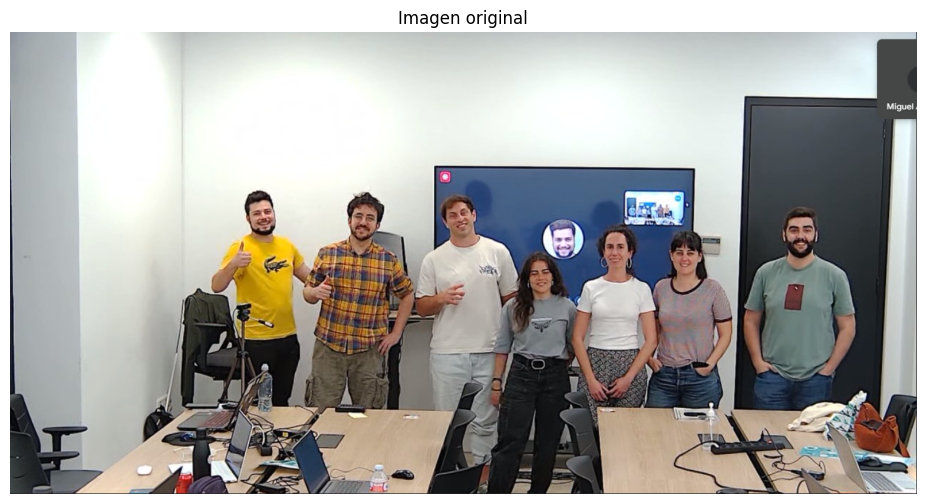

In [3]:
# Una imagen en numpy es un array con forma (alto, ancho, 3):
#   - alto: numero de filas (pixeles verticales)
#   - ancho: numero de columnas (pixeles horizontales)
#   - 3: los tres canales RGB (Rojo, Verde, Azul). Cada pixel es un trio (R, G, B)
#
# imshow se encarga de pintar el array como una imagen.
# axis('off') quita los ejes (los numeros de fila y columna) para que se vea limpio.
plt.figure(figsize=(12, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Imagen original')
plt.show()

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [4]:
# Por que tenemos que hacer este reshape?
# K-Means espera recibir una tabla 2D donde cada FILA es una observacion y cada
# COLUMNA es una caracteristica. En nuestro caso:
#   - cada observacion es UN pixel
#   - las caracteristicas de cada pixel son sus 3 valores RGB
#
# Por eso pasamos de (alto, ancho, 3) a (alto*ancho, 3): aplastamos el alto y
# el ancho en una sola dimension de 'numero total de pixeles'.
#
# Guardamos la forma original para poder reconstruir la imagen al final
forma_original = image.shape
print(f'Forma original: {forma_original}')

# El truco del -1 en reshape: numpy calcula automaticamente esa dimension.
# Si la imagen es (764, 1499, 3), -1 sera 764*1499 = 1.144.636 pixeles.
pixeles = image.reshape(-1, 3)
print(f'Forma nueva (cada fila es un pixel): {pixeles.shape}')

Forma original: (764, 1499, 3)
Forma nueva (cada fila es un pixel): (1145236, 3)


#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [5]:
# La idea clave: si tenemos un millon de pixeles y le decimos a K-Means que
# busque K=8 grupos, lo que hace es buscar los 8 colores que mejor 'representan'
# a todos los pixeles de la imagen. Cada centroide es un color (R, G, B).
#
# Despues sustituiremos cada pixel por el color del centroide al que pertenece,
# y la imagen pasara de tener miles de colores distintos a tener solo K colores.
n_colores = 8

# n_init=10: corremos K-Means 10 veces con inicializaciones distintas y nos
# quedamos con la mejor (asi evitamos minimos locales malos).
# random_state=42: fijamos la aleatoriedad para que el resultado sea reproducible.
kmeans = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
kmeans.fit(pixeles)

print(f'K-Means entrenado con {n_colores} clusters (colores)')
print(f'Forma de los centroides: {kmeans.cluster_centers_.shape}')
print(f'Los {n_colores} colores que ha encontrado:')
print(kmeans.cluster_centers_)

K-Means entrenado con 8 clusters (colores)
Forma de los centroides: (8, 3)
Los 8 colores que ha encontrado:
[[0.82704806 0.83974755 0.8209233 ]
 [0.27446887 0.24944544 0.24767831]
 [0.54404104 0.48578566 0.45721665]
 [0.9571457  0.974525   0.957778  ]
 [0.10057992 0.09515041 0.10361925]
 [0.77467227 0.5832762  0.11056319]
 [0.71568406 0.6896763  0.6569563 ]
 [0.28152558 0.3472503  0.44764182]]


#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [6]:
# Tras entrenar K-Means tenemos dos cosas utiles:
#   - cluster_centers_: array con los K centroides (los K colores). Forma (K, 3).
#   - labels_: array con la etiqueta de cluster de cada pixel. Forma (n_pixeles,).
#
# Para construir la imagen nueva, lo que queremos es:
# para cada pixel, mirar a que cluster pertenece (labels_) y poner como nuevo
# valor el centroide de ese cluster.
#
# Esto se hace en una sola linea con indexacion avanzada de numpy:
# centroides[etiquetas] coge el centroide correspondiente a cada etiqueta.
centroides = kmeans.cluster_centers_
etiquetas = kmeans.labels_

pixeles_nuevos = centroides[etiquetas]

print(f'Forma de los pixeles nuevos: {pixeles_nuevos.shape}')
print('Primer pixel original:', pixeles[0])
print('Primer pixel nuevo:   ', pixeles_nuevos[0])
print(f'(El primer pixel pertenecia al cluster {etiquetas[0]})')

Forma de los pixeles nuevos: (1145236, 3)
Primer pixel original: [0.5686275  0.5803922  0.61960787]
Primer pixel nuevo:    [0.71568406 0.6896763  0.6569563 ]
(El primer pixel pertenecia al cluster 6)


#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [7]:
# Ahora hacemos el reshape inverso al del paso 3:
# pasamos de (alto*ancho, 3) de vuelta a (alto, ancho, 3).
# Por eso era util haber guardado 'forma_original' antes.
imagen_final = pixeles_nuevos.reshape(forma_original)

print(f'Forma de la imagen final: {imagen_final.shape}')

Forma de la imagen final: (764, 1499, 3)


#### 7. Muestra y guarda en tu ordenador la imagen resultante

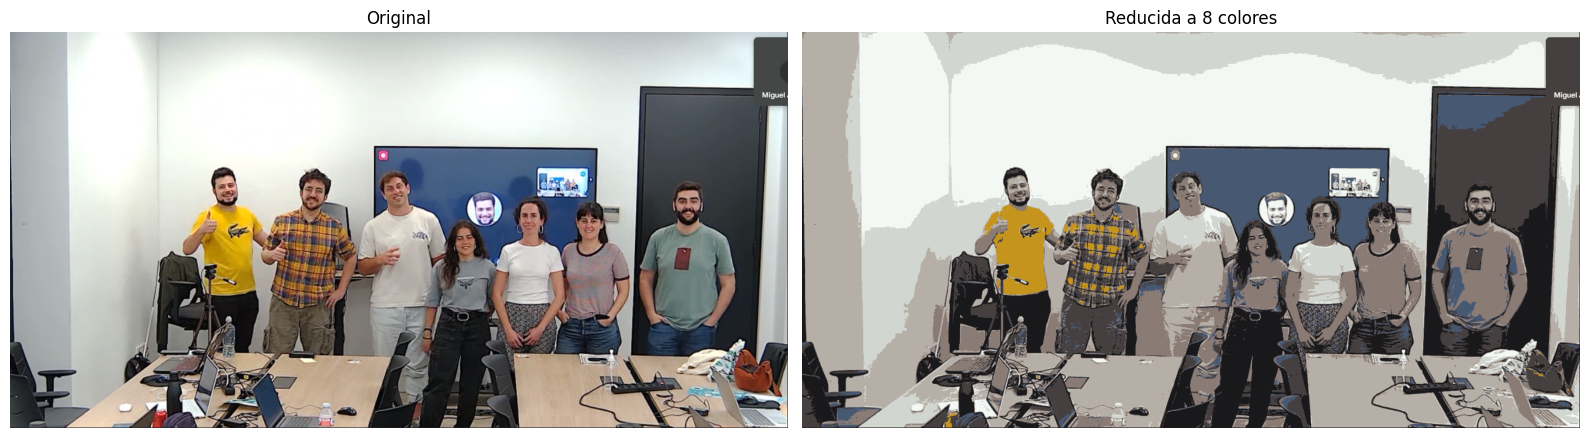

Imagen guardada como imagen_8_colores.png


In [8]:
# Pintamos la imagen original y la nueva una al lado de la otra para comparar.
# subplots(1, 2) crea una figura con 1 fila y 2 columnas de subplots.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(imagen_final)
axes[1].set_title(f'Reducida a {n_colores} colores')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Guardamos la imagen en el disco con plt.imsave.
# Le pasamos la ruta donde queremos guardarla y el array de la imagen.
plt.imsave(f'imagen_{n_colores}_colores.png', imagen_final)
print(f'Imagen guardada como imagen_{n_colores}_colores.png')

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla


--- 2 colores ---


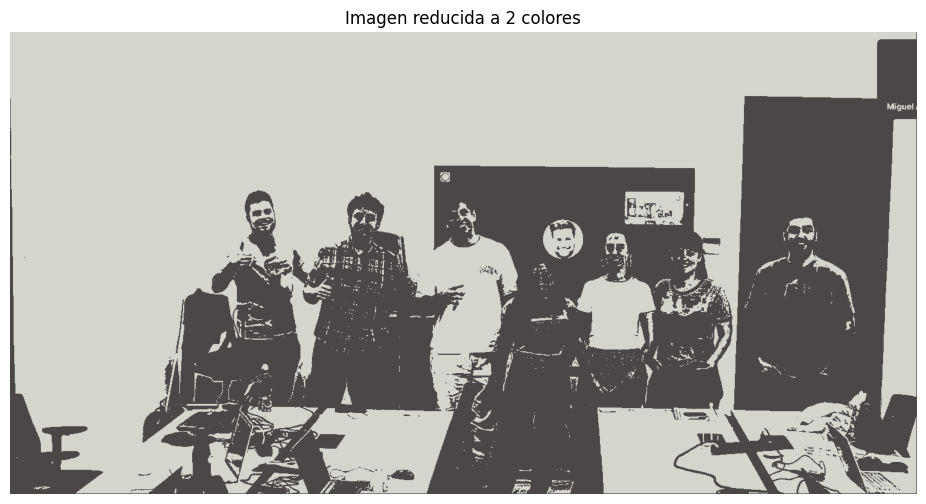


--- 4 colores ---


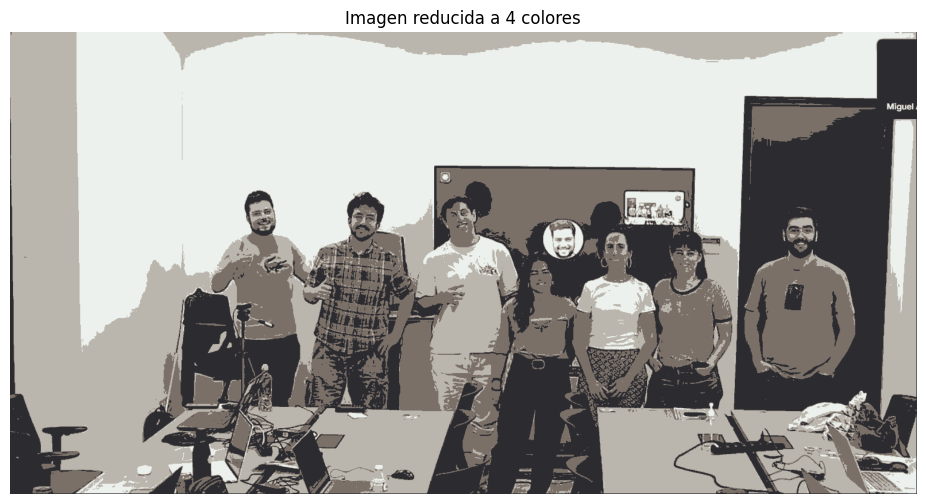


--- 8 colores ---


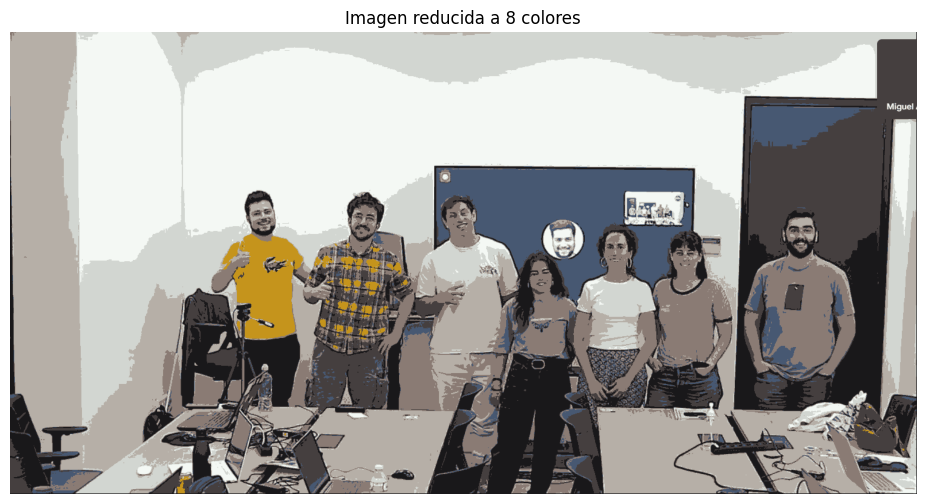


--- 16 colores ---


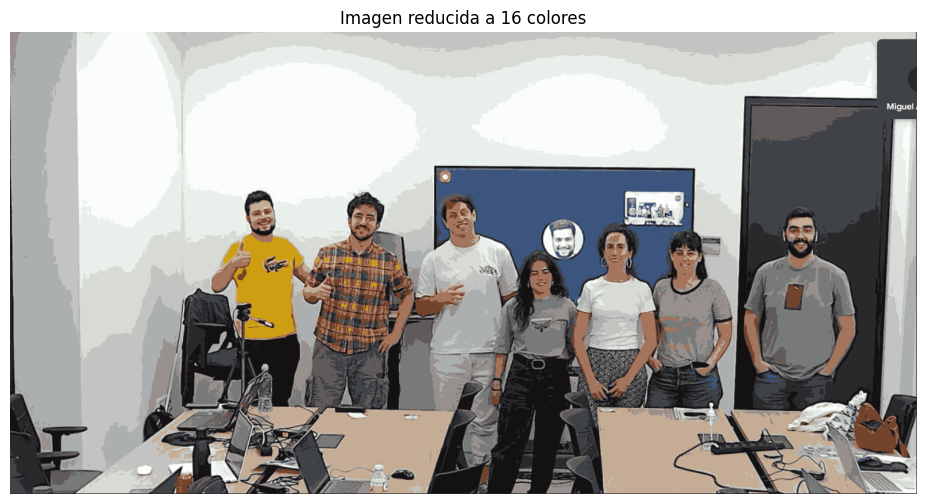

In [9]:
# Recogemos toda la logica de los pasos 3-7 en una sola funcion reutilizable.
# Asi podemos llamarla con distintas imagenes y distintos valores de K sin
# tener que repetir el codigo cada vez.
def cuantizar_colores(imagen, n_colores, modo='mostrar', ruta_guardado=None):
    """
    Reduce el numero de colores de una imagen aplicando K-Means.

    Parametros
    ----------
    imagen : np.ndarray
        Array con la imagen, de forma (alto, ancho, 3).
    n_colores : int
        Numero de colores que tendra la imagen de salida (sera el K de K-Means).
    modo : str
        'mostrar' para pintar la imagen por pantalla, 'guardar' para escribirla
        en el disco.
    ruta_guardado : str, opcional
        Ruta donde guardar la imagen si modo='guardar'.
        Si no se pasa, se genera automaticamente.

    Devuelve
    -------
    imagen_resultado : np.ndarray
        La imagen con los colores reducidos, misma forma que la original.
    """
    # Paso 3: aplastamos la imagen para que cada fila sea un pixel
    forma = imagen.shape
    pixeles = imagen.reshape(-1, 3)

    # Paso 4: entrenamos K-Means con K = numero de colores deseado
    kmeans = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
    kmeans.fit(pixeles)

    # Paso 5: sustituimos cada pixel por el centroide de su cluster
    pixeles_nuevos = kmeans.cluster_centers_[kmeans.labels_]

    # Paso 6: reshape inverso para volver a la forma de imagen
    imagen_resultado = pixeles_nuevos.reshape(forma)

    # Paso 7: mostramos o guardamos segun lo que nos hayan pedido
    if modo == 'mostrar':
        plt.figure(figsize=(12, 6))
        plt.imshow(imagen_resultado)
        plt.axis('off')
        plt.title(f'Imagen reducida a {n_colores} colores')
        plt.show()
    elif modo == 'guardar':
        # Si no nos han dado ruta, generamos un nombre por defecto
        if ruta_guardado is None:
            ruta_guardado = f'imagen_{n_colores}_colores.png'
        plt.imsave(ruta_guardado, imagen_resultado)
        print(f'Imagen guardada en: {ruta_guardado}')
    else:
        raise ValueError("modo debe ser 'mostrar' o 'guardar'")

    return imagen_resultado

# Probamos la funcion con distintos valores de K para ver el efecto
for k in [2, 4, 8, 16]:
    print(f'\n--- {k} colores ---')
    cuantizar_colores(image, n_colores=k, modo='mostrar')